# Amazon Alexa Reviews — Sentiment Analysis
### SVM-based Pipeline with Model Persistence

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download("stopwords")
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english")) - {"not", "no", "never", "n't"}

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import MaxAbsScaler          # ← preserves sparsity, ideal for TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score)
from imblearn.over_sampling import SMOTE               # ← SMOTE for imbalance
from wordcloud import WordCloud
import pickle, re, os, json

os.makedirs("Models", exist_ok=True)
print("All libraries imported successfully.")


[nltk_data] Downloading package stopwords to /Users/rohit/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


All libraries imported successfully.


## 1. Exploratory Data Analysis

In [2]:
# Load the dataset — place amazon_alexa.tsv inside a Data/ folder
data = pd.read_csv("Data/amazon_alexa.tsv", delimiter="	", quoting=3)
print(f"Dataset shape: {data.shape}")

Dataset shape: (3150, 5)


In [3]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [4]:
print(f"Feature names: {data.columns.values}")

Feature names: ['rating' 'date' 'variation' 'verified_reviews' 'feedback']


In [5]:
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [6]:
data[data["verified_reviews"].isna() == True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [7]:
data.dropna(inplace=True)
print(f"Dataset shape after dropping null values: {data.shape}")

Dataset shape after dropping null values: (3149, 5)


In [8]:
data["length"] = data["verified_reviews"].apply(len)
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


### Datatypes

In [9]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

### Analyzing "rating" column

In [10]:
print(f"Rating value count:{data['rating'].value_counts()}")

Rating value count:rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64


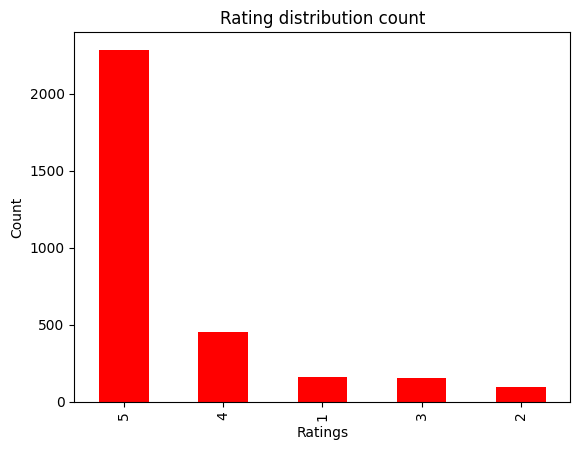

In [11]:
data["rating"].value_counts().plot.bar(color="red")
plt.title("Rating distribution count")
plt.xlabel("Ratings"); plt.ylabel("Count"); plt.show()

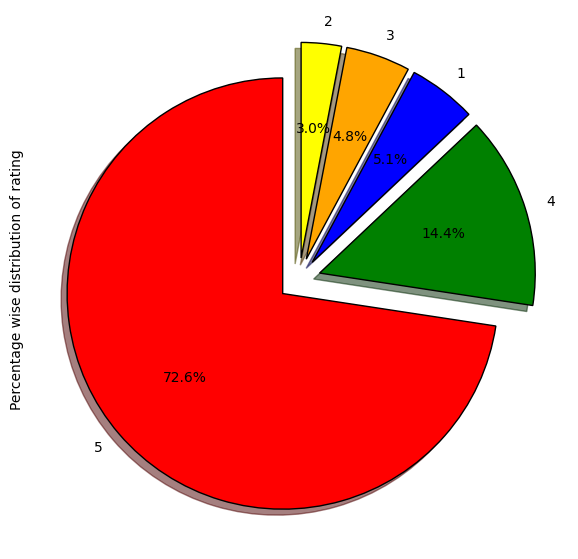

In [12]:
fig = plt.figure(figsize=(7,7))
colors = ("red","green","blue","orange","yellow")
wp = {"linewidth":1,"edgecolor":"black"}
tags = data["rating"].value_counts()/data.shape[0]
explode = (0.1,0.1,0.1,0.1,0.1)
tags.plot(kind="pie", autopct="%1.1f%%", shadow=True, colors=colors,
          startangle=90, wedgeprops=wp, explode=explode,
          label="Percentage wise distribution of rating")
plt.show()

### Analyzing "feedback" column

In [13]:
print(f"Feedback value count{data['feedback'].value_counts()}")
print(f"Feedback % distribution:{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

Feedback value countfeedback
1    2893
0     256
Name: count, dtype: int64
Feedback % distribution:feedback
1    91.87
0     8.13
Name: count, dtype: float64


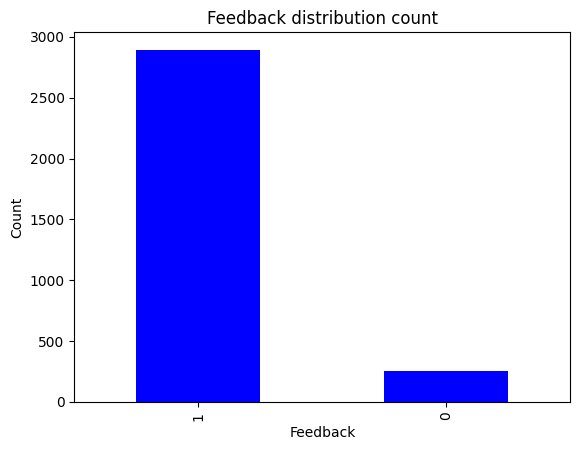

In [14]:
data["feedback"].value_counts().plot.bar(color="blue")
plt.title("Feedback distribution count")
plt.xlabel("Feedback"); plt.ylabel("Count"); plt.show()

### Analyzing "variation" column

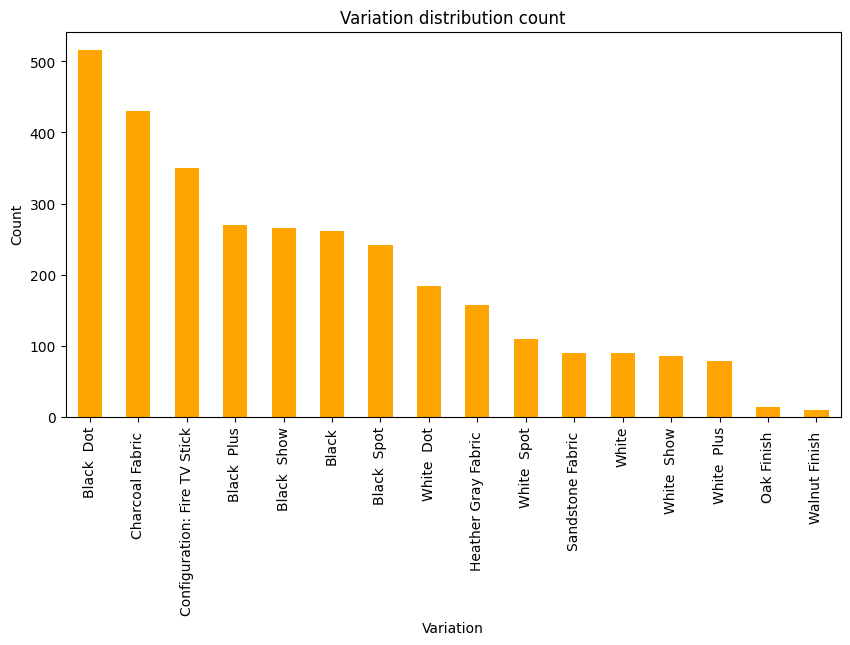

In [15]:
data["variation"].value_counts().plot.bar(color="orange", figsize=(10,5))
plt.title("Variation distribution count")
plt.xlabel("Variation"); plt.ylabel("Count"); plt.show()

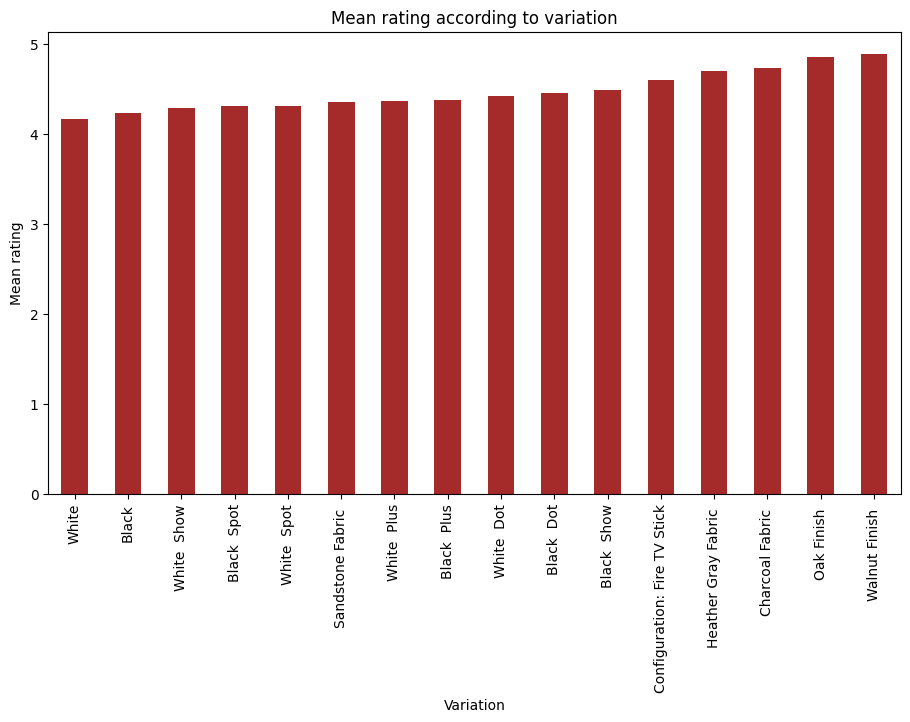

In [16]:
data.groupby("variation")["rating"].mean().sort_values().plot.bar(
    color="brown", figsize=(11,6))
plt.title("Mean rating according to variation")
plt.xlabel("Variation"); plt.ylabel("Mean rating"); plt.show()

### Analyzing "verified_reviews" column

count    3149.000000
mean      132.714513
std       182.541531
min         1.000000
25%        30.000000
50%        74.000000
75%       166.000000
max      2853.000000
Name: length, dtype: float64


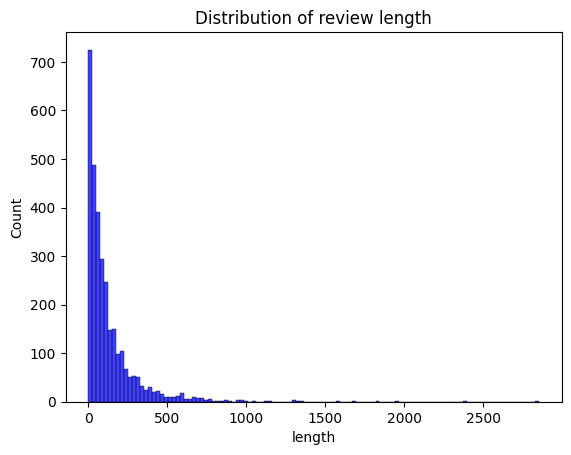

In [17]:
print(data["length"].describe())
sns.histplot(data["length"], color="blue").set(title="Distribution of review length")
plt.show()

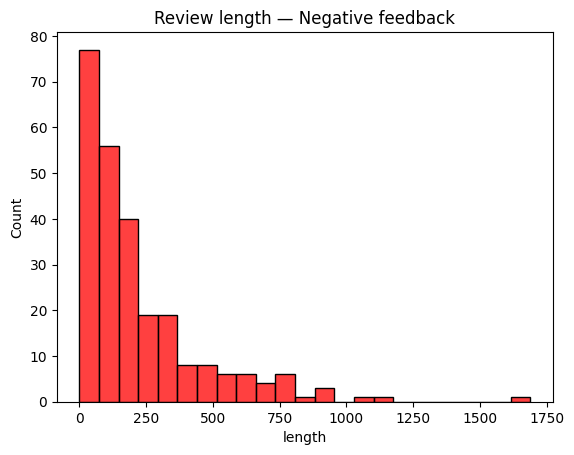

In [18]:
sns.histplot(data[data["feedback"]==0]["length"], color="red").set(
    title="Review length — Negative feedback")
plt.show()

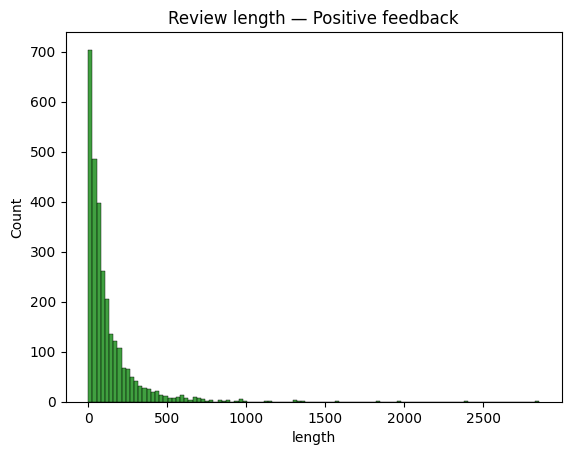

In [19]:
sns.histplot(data[data["feedback"]==1]["length"], color="green").set(
    title="Review length — Positive feedback")
plt.show()

### Word Clouds

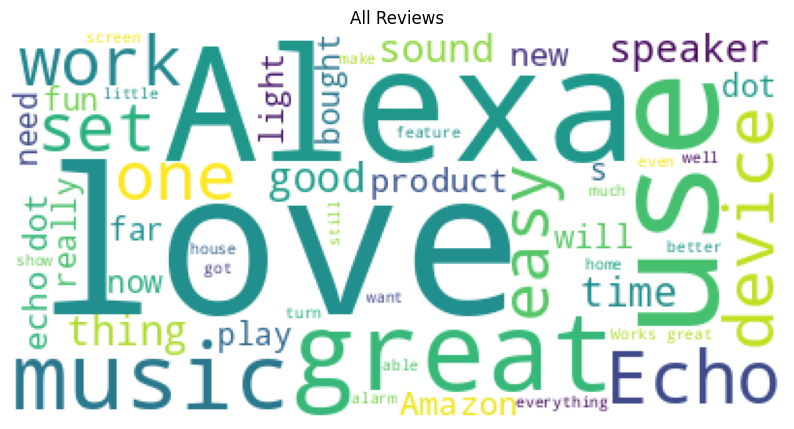

In [20]:
reviews = " ".join(data["verified_reviews"])
wc = WordCloud(background_color="white", max_words=50)
plt.figure(figsize=(10,6))
plt.imshow(wc.generate(reviews)); plt.title("All Reviews"); plt.axis("off"); plt.show()

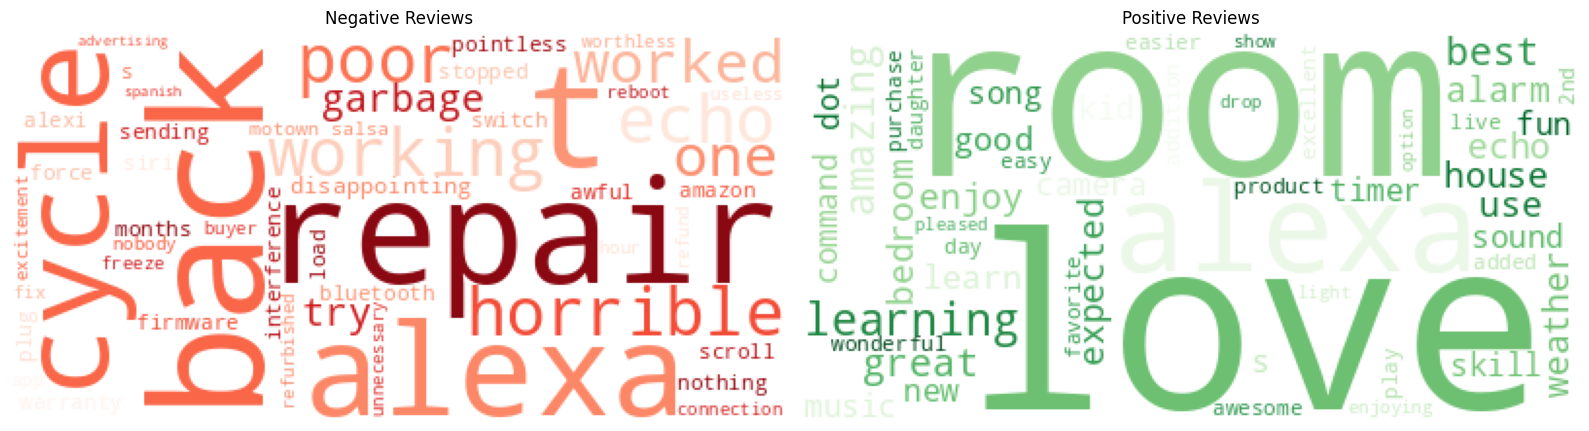

In [21]:
neg_reviews = " ".join(data[data["feedback"]==0]["verified_reviews"])
pos_reviews = " ".join(data[data["feedback"]==1]["verified_reviews"])
unique_neg = " ".join([w for w in neg_reviews.lower().split() if w not in pos_reviews.lower().split()])
unique_pos = " ".join([w for w in pos_reviews.lower().split() if w not in neg_reviews.lower().split()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
wc = WordCloud(background_color="white", max_words=50, colormap="Reds")
ax1.imshow(wc.generate(unique_neg)); ax1.set_title("Negative Reviews"); ax1.axis("off")
wc2 = WordCloud(background_color="white", max_words=50, colormap="Greens")
ax2.imshow(wc2.generate(unique_pos)); ax2.set_title("Positive Reviews"); ax2.axis("off")
plt.tight_layout(); plt.show()

## 2. Preprocessing Pipeline

In [22]:
def expand_contractions(text):
    text = text.lower()
    text = text.replace("don't", "do not")
    text = text.replace("doesn't", "does not")
    text = text.replace("didn't", "did not")
    text = text.replace("isn't", "is not")
    text = text.replace("wasn't", "was not")
    text = text.replace("weren't", "were not")
    text = text.replace("can't", "can not")
    text = text.replace("won't", "will not")
    return text

In [23]:
stemmer = PorterStemmer()

STOPWORDS = set(stopwords.words("english")) - {"not", "no", "never", "n't"}

corpus = []

for i in range(data.shape[0]):
    review = expand_contractions(data.iloc[i]["verified_reviews"])

    review = re.sub("[^a-zA-Z]", " ", review)
    review = review.lower().split()

    tokens = []
    for j, word in enumerate(review):
        if j > 0 and review[j-1] in ["not", "no", "never"]:
            tokens.append("not_" + stemmer.stem(word))
        elif word not in STOPWORDS:
            tokens.append(stemmer.stem(word))

    corpus.append(" ".join(tokens))

In [24]:
# Step 2 — Define y, then split corpus BEFORE vectorizing
y = data["feedback"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    corpus, y, test_size=0.3, random_state=15, stratify=y)

print(f"Train size: {len(X_train_raw)} | Test size: {len(X_test_raw)}")
print(f"y_train — Neg: {(y_train==0).sum()} | Pos: {(y_train==1).sum()}")
print(f"y_test  — Neg: {(y_test==0).sum()}  | Pos: {(y_test==1).sum()}")

Train size: 2204 | Test size: 945
y_train — Neg: 179 | Pos: 2025
y_test  — Neg: 77  | Pos: 868


In [25]:
# Step 3 — Now fit TF-IDF only on train data
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_raw)  # fit+transform on train only
X_test  = tfidf.transform(X_test_raw)       # transform test with train vocab

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (2204, 3000) | X_test: (945, 3000)


## 2b. Handling Class Imbalance with SMOTE

The Alexa dataset is highly imbalanced (~92 % Positive / ~8 % Negative).  
**SMOTE** (Synthetic Minority Over-sampling Technique) creates synthetic minority-class  
samples in the TF-IDF feature space, so the model sees a balanced training set.

**Scaler choice — MaxAbsScaler:**  
- Scales each feature by its maximum absolute value → range **[−1, 1]**, or **[0, 1]** for non-negative TF-IDF  
- Crucially, it **preserves sparsity** (no centering step), making it the ideal scaler for sparse TF-IDF matrices  
- SMOTE requires a dense matrix, so we convert to dense **after** MaxAbsScaler

**Key rules applied to prevent data leakage:**
1. Split raw text → train / test *first*  
2. Fit TF-IDF on train only, then transform both  
3. Fit MaxAbsScaler on train only, then transform both  
4. Convert to dense (`.toarray()`) for SMOTE  
5. Apply SMOTE **only to training data** — test set is never touched


In [26]:
# Step 4 — Scale with MaxAbsScaler (preserves sparsity), then apply SMOTE
# MaxAbsScaler scales each feature by its max absolute value → [0,1] for TF-IDF
# It is the preferred scaler for sparse matrices (no centering, no data leakage).
# SMOTE needs a dense array, so we call .toarray() AFTER scaling.

scaler = MaxAbsScaler()
X_train_scl_sparse = scaler.fit_transform(X_train)   # sparse, [0,1]
X_test_scl_sparse  = scaler.transform(X_test)         # sparse, [0,1]

# Convert to dense only for SMOTE — test set stays sparse until predict
X_train_scl = X_train_scl_sparse.toarray()
X_test_scl  = X_test_scl_sparse.toarray()

print(f"Before SMOTE — y_train: Neg={(y_train==0).sum()} | Pos={(y_train==1).sum()}")

# ── SMOTE ──────────────────────────────────────────────────────────────────
# Applied ONLY on training data; test set is untouched (no data leakage).
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scl, y_train)

print(f"After  SMOTE — y_train_bal: Neg={(y_train_bal==0).sum()} | Pos={(y_train_bal==1).sum()}")
print(f"X_train_bal shape: {X_train_bal.shape} | X_test_scl shape: {X_test_scl.shape}")


Before SMOTE — y_train: Neg=179 | Pos=2025
After  SMOTE — y_train_bal: Neg=2025 | Pos=2025
X_train_bal shape: (4050, 3000) | X_test_scl shape: (945, 3000)


## 3. SVM Modelling with Hyperparameter Tuning

**Why SVM for text classification?**
- Effective in high-dimensional sparse feature spaces (3000-dim TF-IDF)
- Maximises the margin between classes → good generalisation
-  handles the 92%/8% class imbalance
- Linear kernel is exceptionally competitive for NLP tasks

**GridSearchCV** will try all combinations of:
-  ∈ {0.01, 0.1, 1, 10, 100}
-  ∈ {linear, rbf, poly, sigmoid}
-  ∈ {scale, auto}

→ 40 param combos × 5-fold stratified CV = **200 fits**

In [27]:
# GridSearchCV on SMOTE-balanced training data
# class_weight is NOT needed when using SMOTE (data is already balanced),
# but we keep it as an extra safety net.

param_grid = {
    "C": [0.01, 0.1, 0.3, 0.5, 1, 2, 3, 5, 10],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=2000
    ),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train_bal, y_train_bal)   # ← SMOTE-balanced data
print(f"Best Params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_*100:.2f}%")


Fitting 5 folds for each of 9 candidates, totalling 45 fits


Best Params : {'C': 0.5}
Best CV F1  : 95.52%


## 4. Train Best SVM Model

In [28]:
best_C = grid_search.best_params_["C"]
print(f"Training Best LinearSVC with C={best_C} on SMOTE-balanced data")

base_model = LinearSVC(
    C=best_C,
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

# CalibratedClassifierCV wraps LinearSVC to add predict_proba support
model_svm = CalibratedClassifierCV(base_model, cv=5)
model_svm.fit(X_train_bal, y_train_bal)    # ← SMOTE-balanced data

# Evaluate on the ORIGINAL (unbalanced) test set — gives real-world metrics
y_pred = model_svm.predict(X_test_scl)

print(f"Training Accuracy : {model_svm.score(X_train_bal, y_train_bal)*100:.2f}%")
print(f"Testing  Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")


Training Best LinearSVC with C=0.5 on SMOTE-balanced data
Training Accuracy : 98.59%
Testing  Accuracy : 91.53%


In [29]:
y_pred = model_svm.predict(X_test_scl)
y_prob = model_svm.predict_proba(X_test_scl)[:, 1]

print("Classification Report (default threshold=0.5):")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))
print(f"Macro F1 Score : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"ROC-AUC Score  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Accuracy       : {accuracy_score(y_test, y_pred)*100:.2f}%")


Classification Report (default threshold=0.5):
              precision    recall  f1-score   support

    Negative       0.48      0.55      0.51        77
    Positive       0.96      0.95      0.95       868

    accuracy                           0.92       945
   macro avg       0.72      0.75      0.73       945
weighted avg       0.92      0.92      0.92       945

Macro F1 Score : 0.7329
ROC-AUC Score  : 0.9016
Accuracy       : 91.53%


In [30]:
from sklearn.metrics import f1_score
import numpy as np

# Find the best threshold by trying values from 0.1 to 0.9
y_prob = model_svm.predict_proba(X_test_scl)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    macro_f1 = f1_score(y_test, y_pred_thresh, average="macro")
    neg_recall = f1_score(y_test, y_pred_thresh, average=None)[0]
    pos_recall = f1_score(y_test, y_pred_thresh, average=None)[1]
    results.append((thresh, macro_f1, neg_recall, pos_recall))

# Print all threshold results
print(f"{'Threshold':>10} {'Macro F1':>10} {'Neg F1':>10} {'Pos F1':>10}")
print("-" * 45)
for thresh, macro, neg, pos in results:
    print(f"{thresh:>10.2f} {macro:>10.4f} {neg:>10.4f} {pos:>10.4f}")

# Pick best threshold by macro F1
best = max(results, key=lambda x: x[1])
print(f"\nBest Threshold : {best[0]:.2f}")
print(f"Best Macro F1  : {best[1]:.4f}")

 Threshold   Macro F1     Neg F1     Pos F1
---------------------------------------------
      0.10     0.7153     0.4655     0.9651
      0.15     0.7198     0.4746     0.9650
      0.20     0.7195     0.4832     0.9558
      0.25     0.7138     0.4737     0.9540
      0.30     0.7138     0.4737     0.9540
      0.35     0.7117     0.4713     0.9521
      0.40     0.7318     0.5093     0.9543
      0.45     0.7367     0.5185     0.9549
      0.50     0.7329     0.5122     0.9537
      0.55     0.7274     0.5030     0.9518
      0.60     0.7321     0.5119     0.9524
      0.65     0.7285     0.5059     0.9512
      0.70     0.7267     0.5029     0.9506
      0.75     0.7198     0.4914     0.9481
      0.80     0.7203     0.4945     0.9461
      0.85     0.7086     0.4767     0.9405

Best Threshold : 0.45
Best Macro F1  : 0.7367


In [31]:
# Final evaluation at threshold 0.65
best_threshold = 0.65

y_pred_final = (y_prob >= best_threshold).astype(int)

print(f"Classification Report at threshold = {best_threshold}:")
print(classification_report(y_test, y_pred_final, target_names=["Negative", "Positive"]))
print(f"Macro F1 Score : {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"ROC-AUC Score  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Accuracy       : {accuracy_score(y_test, y_pred_final)*100:.2f}%")

Classification Report at threshold = 0.65:
              precision    recall  f1-score   support

    Negative       0.46      0.56      0.51        77
    Positive       0.96      0.94      0.95       868

    accuracy                           0.91       945
   macro avg       0.71      0.75      0.73       945
weighted avg       0.92      0.91      0.91       945

Macro F1 Score : 0.7285
ROC-AUC Score  : 0.9016
Accuracy       : 91.11%


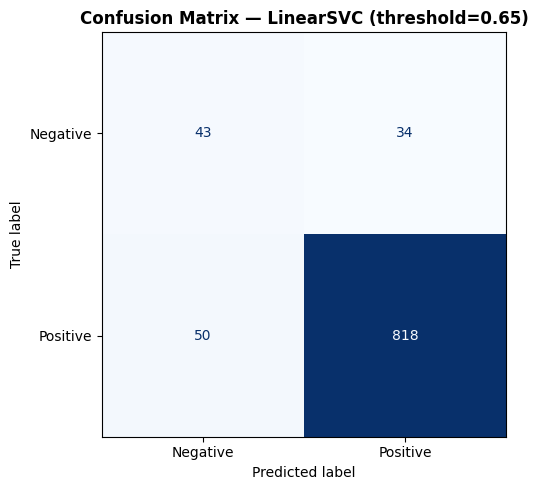

In [32]:
# Confusion Matrix at best threshold 0.65
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — LinearSVC (threshold=0.65)", fontweight="bold")
plt.tight_layout()
plt.show()

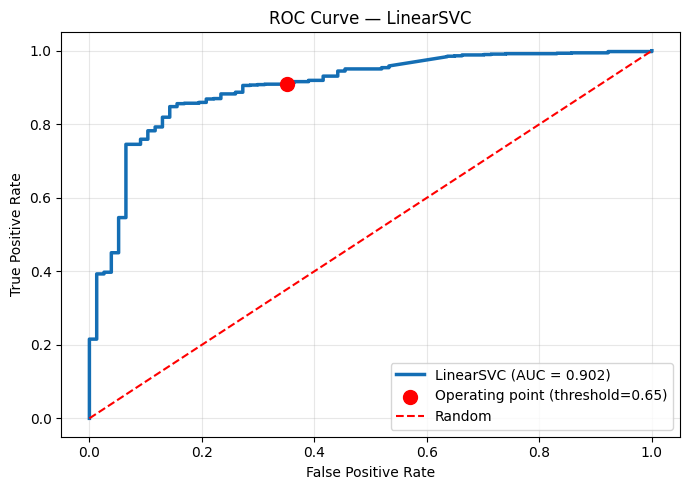

In [33]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#146EB4", lw=2.5,
         label=f"LinearSVC (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.scatter(*[(fpr[i], tpr[i]) for i in range(len(fpr))
              if abs(fpr[i] - (1 - 0.65)) < 0.02][:1][0],
            color="red", zorder=5, s=100,
            label=f"Operating point (threshold=0.65)")
plt.plot([0, 1], [0, 1], "r--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LinearSVC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# 5-Fold Cross Validation on SMOTE-balanced training data
cv_scores = cross_val_score(
    CalibratedClassifierCV(
        LinearSVC(C=best_C, class_weight="balanced", random_state=42, max_iter=2000), cv=5),
    X_train_bal, y_train_bal,
    cv=5,
    scoring="f1_macro")

print(f"CV Macro F1 Scores : {[round(s, 4) for s in cv_scores]}")
print(f"CV Mean Macro F1   : {cv_scores.mean()*100:.2f}%")
print(f"CV Std             : {cv_scores.std()*100:.2f}%")


CV Macro F1 Scores : [np.float64(0.9728), np.float64(0.9741), np.float64(0.9778), np.float64(0.9703), np.float64(0.9778)]
CV Mean Macro F1   : 97.46%
CV Std             : 0.29%


/Users/rohit/Downloads/amazon/alexa/Sentiment-Analysis/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
4 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/rohit/Downloads/amazon/alexa/Sentiment-Analysis/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/rohit/Downloads/amazon/alexa/Sentiment-Analysis/venv/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^

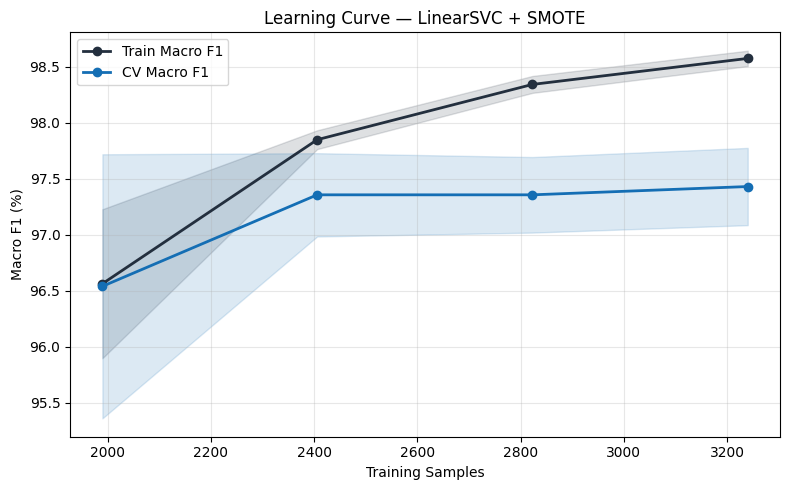

In [35]:
# Learning Curve on SMOTE-balanced data
train_sizes, train_scores, val_scores = learning_curve(
    CalibratedClassifierCV(
        LinearSVC(C=best_C, class_weight="balanced", random_state=42, max_iter=2000), cv=3),
    X_train_bal, y_train_bal,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1)*100, "o-",
         color="#232F3E", label="Train Macro F1", lw=2)
plt.fill_between(train_sizes,
                 (train_scores.mean(axis=1) - train_scores.std(axis=1))*100,
                 (train_scores.mean(axis=1) + train_scores.std(axis=1))*100,
                 alpha=0.15, color="#232F3E")
plt.plot(train_sizes, val_scores.mean(axis=1)*100, "o-",
         color="#146EB4", label="CV Macro F1", lw=2)
plt.fill_between(train_sizes,
                 (val_scores.mean(axis=1) - val_scores.std(axis=1))*100,
                 (val_scores.mean(axis=1) + val_scores.std(axis=1))*100,
                 alpha=0.15, color="#146EB4")
plt.xlabel("Training Samples"); plt.ylabel("Macro F1 (%)")
plt.title("Learning Curve — LinearSVC + SMOTE")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 5. Save All Models & Artefacts

In [36]:
# ── Save everything the Streamlit app needs ──────────────────────────────
# Key alignment with app.py:
#   metrics["best_params"] = {"kernel": "linear", "C": best_C, "gamma": "scale"}
#   metrics["best_cv_f1"], ["train_accuracy"], ["test_accuracy"], etc.
#   scaler  → MaxAbsScaler  (fit on sparse TF-IDF; app.py converts to dense before transform)
#   model   → CalibratedClassifierCV(LinearSVC)  (has predict_proba)

pickle.dump(model_svm, open("Models/model_svm.pkl",        "wb"))
pickle.dump(tfidf,     open("Models/tfidf_vectorizer.pkl", "wb"))
pickle.dump(scaler,    open("Models/scaler.pkl",           "wb"))

# Save threshold
with open("Models/threshold.json", "w") as f:
    json.dump({"best_threshold": best_threshold}, f)

# Recompute predictions at best threshold for saved metrics
y_pred_final = (y_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
fpr, tpr, _ = roc_curve(y_test, y_prob)

metrics_dict = {
    # ── app.py reads metrics["best_params"] as a dict ──
    "best_params": {
        "kernel": "linear",          # LinearSVC is always linear kernel
        "C":      float(best_C),
        "gamma":  "scale"            # not used by LinearSVC; kept for UI display
    },
    "best_threshold":  best_threshold,
    "best_cv_f1":      float(grid_search.best_score_),
    "train_accuracy":  float(model_svm.score(X_train_bal, y_train_bal)),
    "test_accuracy":   float(accuracy_score(y_test, y_pred_final)),
    "macro_f1":        float(f1_score(y_test, y_pred_final, average="macro")),
    "roc_auc":         float(roc_auc_score(y_test, y_prob)),
    "avg_precision":   float(average_precision_score(y_test, y_prob)),
    "cv_f1_mean":      float(cv_scores.mean()),
    "cv_f1_std":       float(cv_scores.std()),
    "classification_report": classification_report(
                                y_test, y_pred_final,
                                target_names=["Negative", "Positive"],
                                output_dict=True),
    "confusion_matrix": cm.tolist(),
    "roc_fpr":  fpr.tolist(),
    "roc_tpr":  tpr.tolist(),
    "dataset_shape":    list(data.shape),
    "positive_count":   int((y==1).sum()),
    "negative_count":   int((y==0).sum()),
    "num_variations":   int(data["variation"].nunique()),
    # SMOTE class balance info
    "smote_balance": {
        "before_neg": int((y_train==0).sum()),
        "before_pos": int((y_train==1).sum()),
        "after_neg":  int((y_train_bal==0).sum()),
        "after_pos":  int((y_train_bal==1).sum()),
    },
    "class_balance": {
        "train_pos": int((y_train==1).sum()),
        "train_neg": int((y_train==0).sum()),
        "test_pos":  int((y_test==1).sum()),
        "test_neg":  int((y_test==0).sum()),
    }
}

with open("Models/metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=2)

data.to_csv("Models/data_processed.csv", index=False)

print("Saved Models/")
print("  model_svm.pkl          — CalibratedClassifierCV(LinearSVC)")
print("  tfidf_vectorizer.pkl   — TfidfVectorizer(3000, bigrams)")
print("  scaler.pkl             — MaxAbsScaler (fit on sparse; dense used for SMOTE & inference)")
print("  threshold.json         — best_threshold")
print("  metrics.json           — all metrics incl. best_params dict")
print("  data_processed.csv")
print()
print("Run: streamlit run app.py")


Saved Models/
  model_svm.pkl          — CalibratedClassifierCV(LinearSVC)
  tfidf_vectorizer.pkl   — TfidfVectorizer(3000, bigrams)
  scaler.pkl             — MaxAbsScaler (fit on sparse; dense used for SMOTE & inference)
  threshold.json         — best_threshold
  metrics.json           — all metrics incl. best_params dict
  data_processed.csv

Run: streamlit run app.py


## 6. (Optional) All Kernel Variants Comparison

In [38]:
import json

with open("Models/metrics.json") as f:
    metrics = json.load(f)

best_params = metrics["best_params"]

print("Loaded best params:", best_params)

Loaded best params: {'kernel': 'linear', 'C': 0.5, 'gamma': 'scale'}


In [39]:
# Train all 4 kernels with best C & gamma for comparison
C_best = best_params["C"]
g_best = best_params.get("gamma", "scale")

variants = {
    "Linear":  SVC(kernel="linear",  C=C_best,          probability=True, random_state=42, class_weight="balanced"),
    "RBF":     SVC(kernel="rbf",     C=C_best, gamma=g_best, probability=True, random_state=42, class_weight="balanced"),
    "Poly":    SVC(kernel="poly",    C=C_best, gamma=g_best, probability=True, random_state=42, class_weight="balanced"),
    "Sigmoid": SVC(kernel="sigmoid", C=C_best, gamma=g_best, probability=True, random_state=42, class_weight="balanced"),
}

print(f"{'Kernel':<10} {'Train Acc':>10} {'Test Acc':>10} {'ROC-AUC':>10}")
print("-" * 45)
kernel_results = {}
for name, mdl in variants.items():
    mdl.fit(X_train_scl, y_train)
    yp   = mdl.predict(X_test_scl)
    ypr  = mdl.predict_proba(X_test_scl)[:,1]
    tr   = mdl.score(X_train_scl, y_train)*100
    te   = accuracy_score(y_test, yp)*100
    auc  = roc_auc_score(y_test, ypr)
    kernel_results[name] = dict(train=tr, test=te, auc=auc, fpr=roc_curve(y_test,ypr)[0], tpr=roc_curve(y_test,ypr)[1], prob=ypr)
    print(f"{name:<10} {tr:>9.2f}% {te:>9.2f}% {auc:>10.4f}")

Kernel      Train Acc   Test Acc    ROC-AUC
---------------------------------------------
Linear         99.05%     93.86%     0.9296
RBF            99.14%     93.23%     0.9326
Poly           98.23%     92.70%     0.9049
Sigmoid        94.01%     88.89%     0.9072


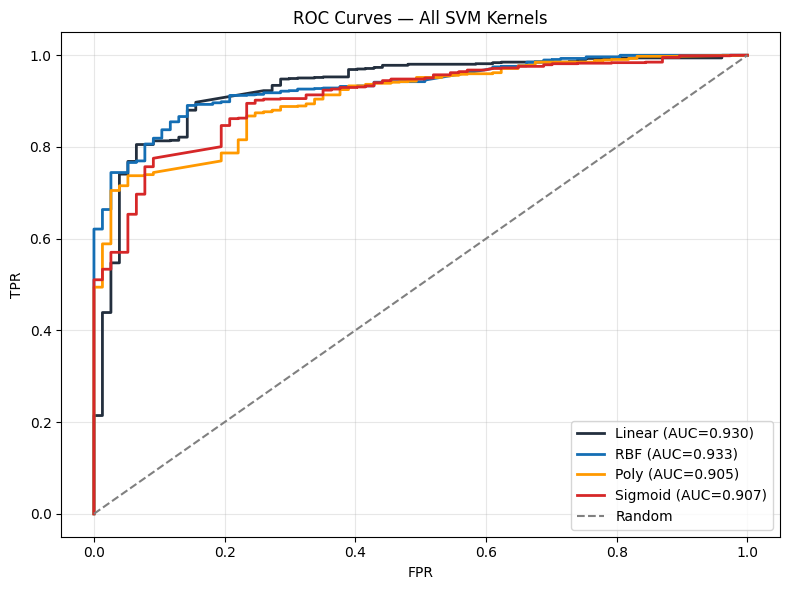

In [40]:
# Combined ROC curves for all kernels
plt.figure(figsize=(8, 6))
colors = ["#232F3E","#146EB4","#FF9900","#d62728"]
for (name, r), col in zip(kernel_results.items(), colors):
    plt.plot(r["fpr"], r["tpr"], color=col, lw=2,
             label=f"{name} (AUC={r['auc']:.3f})")
plt.plot([0,1],[0,1],"gray",linestyle="--",label="Random")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curves — All SVM Kernels"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()